# Phase 5b: Risk Classification

Trains a classifier to predict `risk_proxy_closed` — whether a business has
closed on Yelp — from its structured, sentiment, and text features.

**This predicts a proxy, not real credit risk.** There is no loan default
data in this dataset. `risk_proxy_closed` stands in for "financial
distress," but a business can close for reasons that have nothing to do
with creditworthiness (relocation, retirement, rebranding under a new
listing). Every result in this notebook must be described as "predicting
proxy business closure," never "predicting default" or "predicting credit
risk" without that qualifier — see CLAUDE.md and Phase 4's notebook.

**This is independent of Phase 5a (segmentation)** — it doesn't use the
`segment`/`segment_name` columns at all, just `business_features.csv`
directly. (A quick cross-tab against the Phase 5a segments was done
separately, before building this notebook, as a sanity check — see
`docs/capstone-plan-of-action.md` Phase 5a for the result: closure rate
was actually *lowest* in the worst-sentiment segment, the opposite of the
naive expectation. That's a signal that sentiment/text features may turn
out to be weak predictors here — worth watching for below.)

## Load data and build the feature matrix

**Critical exclusion**: `is_open` is perfectly complementary to
`risk_proxy_closed` by construction (`is_open == 1 - risk_proxy_closed`,
verified with an assertion in Phase 4). It must be dropped from `X` —
otherwise the model gets a trivial 100%-accuracy shortcut that says
nothing about whether sentiment/text signal actually predicts closure.

Also excluded: identifier columns (`business_id`, `name`, `address`,
`postal_code`) and `categories` (raw text — we'll reuse the same top-15
one-hot approach as Phase 5a rather than re-deriving a different encoding
here, for consistency between the two notebooks).

Same as Phase 5a, `stars` and `review_count` are **also excluded** here
(kept only `sentiment_compound_mean` / `review_count_actual`) —
correlated predictors (0.85 and 0.9998 respectively) don't just hurt
k-means specifically; they also make logistic regression coefficients
unstable and hard to interpret cleanly, since the model can arbitrarily
split "credit" for the same underlying signal between two near-duplicate
columns. Since this phase's whole point is explainable coefficients/SHAP
values, that's worth avoiding here even more than in Phase 5a.

In [1]:
import pandas as pd
from collections import Counter

business_features = pd.read_csv('../data/business_features.csv')

numeric_features = [
    'review_count_actual',
    'sentiment_compound_mean',
    'sentiment_compound_std',
    'pct_negative_reviews',
    'pct_positive_reviews',
    'text_word_count_mean',
    'text_exclamation_count_mean',
    'text_question_count_mean',
    'text_caps_word_ratio_mean',
    'category_count',
]

category_lists = business_features['categories'].str.split(',').apply(lambda cats: [c.strip() for c in cats])
top_categories = [cat for cat, _ in Counter(c for cats in category_lists for c in cats).most_common(15)]

category_features = []
for cat in top_categories:
    col = f'cat_{cat.lower().replace(" ", "_").replace("&", "and")}'
    business_features[col] = category_lists.apply(lambda cats: int(cat in cats))
    category_features.append(col)

feature_cols = numeric_features + category_features
X = business_features[feature_cols]
y = business_features['risk_proxy_closed']

X.shape, y.mean()

((14560, 25), np.float64(0.2764423076923077))

## Train/test split, then scale

Split first, scale second — this is the leakage point flagged back in
Phase 4. The scaler's mean/std must be fit on the training data only; if
it were fit on the full dataset before splitting, information from the
test set (via the shared mean/std) would leak into every training row's
scaled values, making the test evaluation overly optimistic.

`stratify=y` keeps the ~27.6% closure rate consistent between train and
test splits — otherwise a random split could accidentally produce, say, a
test set with a very different closure rate than what the model was
trained on.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only — reuses the training mean/std, never refit on test data

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((11648, 25),
 (2912, 25),
 np.float64(0.2764423076923077),
 np.float64(0.2764423076923077))

## Train logistic regression and evaluate

`class_weight='balanced'` adjusts for the 72%/28% class imbalance (open
businesses outnumber closed ones) so the model doesn't just learn to
always predict "open" — without it, a classifier that never predicts
closure would already be ~72% "accurate" while being useless.

We report several metrics, not just accuracy, because accuracy alone is
misleading on imbalanced classes:
- **Accuracy** — overall correct-prediction rate (least informative here)
- **Precision** (for the "closed" class) — of businesses the model flags
  as at-risk, what share actually closed
- **Recall** (for the "closed" class) — of businesses that actually
  closed, what share the model caught
- **ROC-AUC** — how well the model ranks closed vs. open businesses by
  predicted risk, independent of any particular threshold

And a **naive baseline** — always predicting the majority class ("open")
— for comparison. If the model doesn't clearly beat this, it isn't adding
real signal.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.dummy import DummyClassifier

model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic regression ===')
print(classification_report(y_test, y_pred, target_names=['open', 'closed']))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print()

baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train_scaled, y_train)
y_pred_baseline = baseline.predict(X_test_scaled)

# zero_division=0: the baseline never predicts "closed" by design, so precision/recall for that class is undefined — 0 is the expected, correct value here, not an error to chase
print('=== Naive baseline (always predict "open") ===')
print(classification_report(y_test, y_pred_baseline, target_names=['open', 'closed'], zero_division=0))

=== Logistic regression ===
              precision    recall  f1-score   support

        open       0.86      0.65      0.74      2107
      closed       0.44      0.72      0.54       805

    accuracy                           0.67      2912
   macro avg       0.65      0.68      0.64      2912
weighted avg       0.74      0.67      0.68      2912

ROC-AUC: 0.7427981852859589

=== Naive baseline (always predict "open") ===
              precision    recall  f1-score   support

        open       0.72      1.00      0.84      2107
      closed       0.00      0.00      0.00       805

    accuracy                           0.72      2912
   macro avg       0.36      0.50      0.42      2912
weighted avg       0.52      0.72      0.61      2912



### Confirming: is 0.72 recall from class weighting, or natural behavior?

Only **class weighting** (`class_weight='balanced'`) was used — no
resampling (no SMOTE, no manual oversampling/undersampling of the training
rows). To show this actually matters, rather than just asserting it: train
an otherwise-identical model *without* class weighting and compare recall
on the "closed" class directly.

In [4]:
model_unweighted = LogisticRegression(random_state=42, max_iter=1000)  # no class_weight — default behavior
model_unweighted.fit(X_train_scaled, y_train)
y_pred_unweighted = model_unweighted.predict(X_test_scaled)

print('=== Logistic regression, NO class weighting (default) ===')
print(classification_report(y_test, y_pred_unweighted, target_names=['open', 'closed'], zero_division=0))

=== Logistic regression, NO class weighting (default) ===
              precision    recall  f1-score   support

        open       0.77      0.95      0.85      2107
      closed       0.65      0.25      0.36       805

    accuracy                           0.76      2912
   macro avg       0.71      0.60      0.61      2912
weighted avg       0.74      0.76      0.71      2912



## Confusion matrix (weighted model)

Raw counts behind the precision/recall/accuracy numbers above, for the
actual model used (`class_weight='balanced'`).

                predicted: open  predicted: closed
actual: open               1369                738
actual: closed              229                576


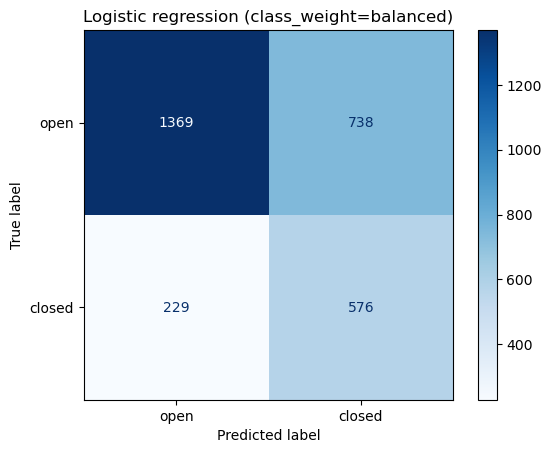

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=['actual: open', 'actual: closed'], columns=['predicted: open', 'predicted: closed']))

ConfusionMatrixDisplay(cm, display_labels=['open', 'closed']).plot(cmap='Blues')
plt.title('Logistic regression (class_weight=balanced)')
plt.show()

### Confirmed: 0.72 recall comes from class weighting, not natural behavior

Without `class_weight='balanced'`, recall on the "closed" class collapses
from **0.72 to 0.25** — the unweighted model catches only 1 in 4 businesses
that actually closed, reverting to the same majority-class bias as the
naive baseline. Meanwhile its raw accuracy is *higher* (0.76 vs. 0.67) —
the same misleading-accuracy pattern seen earlier, now demonstrated with a
direct side-by-side comparison rather than just asserted. This confirms
class weighting is doing real, necessary work here, and that accuracy
alone would have hidden that.

**Confusion matrix (weighted model)**: of 805 businesses that actually
closed, the model correctly flagged 576 (recall 0.72) and missed 229. Of
2,107 that stayed open, it correctly identified 1,369 but incorrectly
flagged 738 as at-risk (which is where the 0.44 precision comes from:
576 / (576 + 738)).

### Reading these results

The naive baseline's raw accuracy (0.72) is actually *higher* than the
model's (0.67) — this is precisely the trap flagged above. The baseline
gets there by never predicting "closed" at all (0.00 recall on the class
we actually care about), which is useless for identifying at-risk
businesses despite the flattering accuracy number.

The model, by contrast: **ROC-AUC of 0.74** (0.5 = random guessing, 1.0 =
perfect ranking) shows real, moderate discriminative power — clearly
better than chance, not close to perfect. **Recall of 0.72** on the
"closed" class means it catches most businesses that actually closed,
at the cost of **precision of 0.44** — many of its "at-risk" flags are
false alarms. That precision/recall trade-off is a direct consequence of
`class_weight='balanced'`, which was a deliberate choice to prioritize
catching closures over minimizing false alarms; a bank-grade system would
tune this trade-off based on the actual cost of a missed closure vs. a
wasted review.

This moderate-but-real signal is consistent with what the Phase 5a
cross-tab suggested: sentiment alone doesn't cleanly separate closed from
open businesses, but the fuller feature set (review volume, category mix,
text patterns together) still carries some genuine predictive signal.
SHAP below will help clarify which features are actually driving it.

## Explainability (SHAP)

This maps to the GDPR Article 22 requirement noted in the plan doc: if a
model like this ever informed a real decision about a business, the
business would have a right to an explanation of *why*. SHAP values give
a per-prediction, per-feature breakdown of how much each feature pushed
the prediction toward "closed" vs. "open," which is a much more concrete
answer than "the model said so."

For a linear model like logistic regression, `LinearExplainer` is exact
(not an approximation) and fast — no need for the sampling-based
explainers required for black-box models.

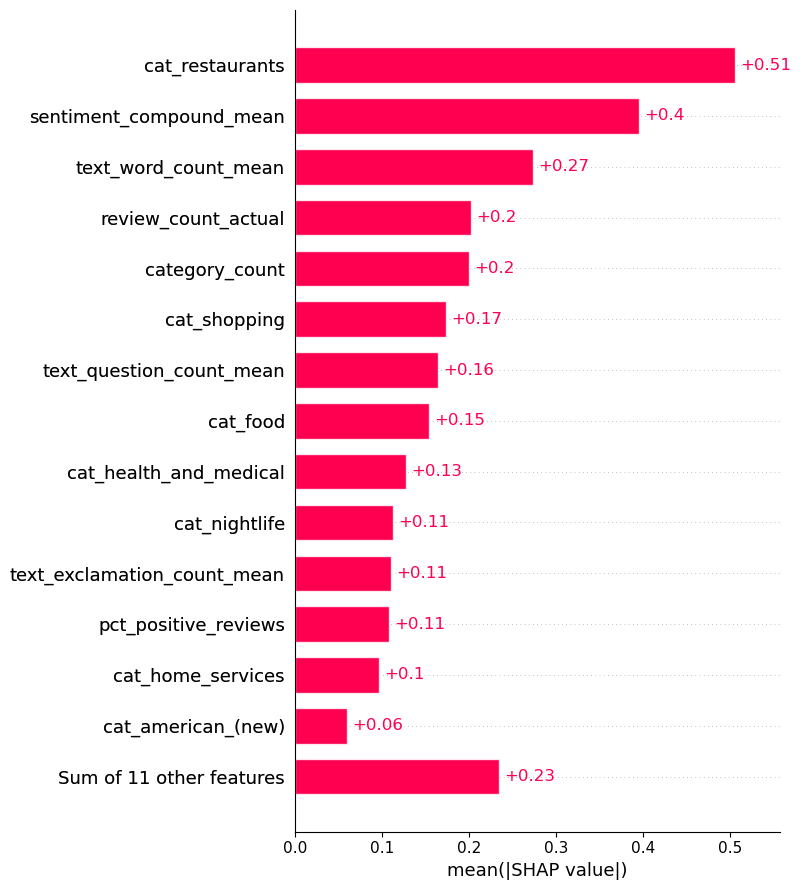

In [6]:
import shap

# masker uses the full training set (only 25 features, trivially fast for a linear model) rather than
# the default 100-sample subsample, so the background distribution is exact, not approximated
masker = shap.maskers.Independent(X_train_scaled, max_samples=X_train_scaled.shape[0])
explainer = shap.Explainer(model, masker=masker, feature_names=feature_cols)
shap_values = explainer(X_test_scaled)

shap.plots.bar(shap_values, max_display=15, show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

The bar chart above ranks features by average impact magnitude, but not
direction. The beeswarm plot below shows both: each dot is one business in
the test set, its color is that business's value for the feature (red =
high, blue = low), and its horizontal position shows whether that pushed
the prediction toward "closed" (right) or "open" (left).

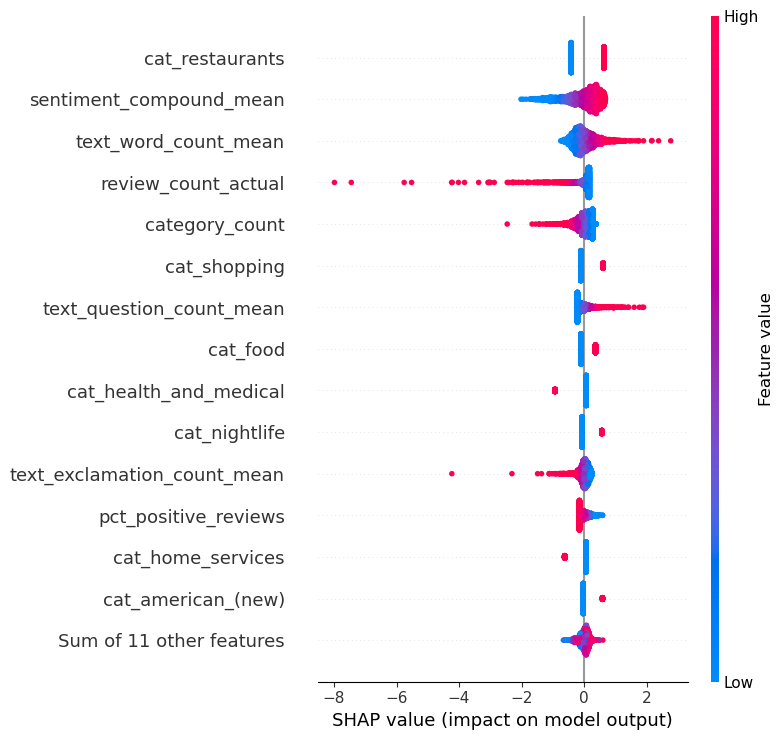

In [7]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.show()

### Reading the SHAP results

The plots above are useful visually, but the exact numbers are worth
pinning down precisely — both the average magnitude of each feature's
impact, and the direction (via the underlying logistic regression
coefficient, since the sign of a linear model's coefficient tells you
the direction unambiguously).

In [8]:
import numpy as np

mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=feature_cols, name='mean_abs_shap')
coefs = pd.Series(model.coef_[0], index=feature_cols, name='coefficient')

shap_summary = pd.concat([mean_abs_shap, coefs], axis=1).sort_values('mean_abs_shap', ascending=False)
shap_summary['direction'] = shap_summary['coefficient'].apply(lambda c: 'higher = more risk' if c > 0 else 'higher = less risk')
shap_summary.head(10)

,mean_abs_shap,coefficient,direction
cat_restaurants,0.505744,0.512725,higher = more risk
sentiment_compound_mean,0.395615,0.506995,higher = more risk
text_word_count_mean,0.273714,0.358035,higher = more risk
review_count_actual,0.202530,-0.471834,higher = less risk
category_count,0.200267,-0.252884,higher = less risk
cat_shopping,0.173424,0.249777,higher = more risk
text_question_count_mean,0.164808,0.246293,higher = more risk
cat_food,0.153798,0.189725,higher = more risk
cat_health_and_medical,0.128327,-0.248965,higher = less risk
cat_nightlife,0.112912,0.190255,higher = more risk


### Interpretation

Two groups of findings, and they tell different stories:

**Intuitive, "makes sense" findings**: being tagged `Restaurants` is the
single strongest risk driver — consistent with the well-known reality that
food service has high failure rates. `review_count_actual` and
`category_count` both reduce risk — more-reviewed, more-established,
more-diversified businesses are more stable, as expected.
`cat_health_and_medical` also reduces risk (a more stable, essential
sector), while `cat_shopping`, `cat_food`, and `cat_nightlife` all
increase it (consistent with retail/hospitality's higher turnover).

**The counter-intuitive finding, confirmed a third time**:
`sentiment_compound_mean` is the **second-strongest** predictor overall —
and higher sentiment means *higher* predicted closure risk, not lower.
This is not a one-off artifact. It's now been observed independently
three times, from three different angles:
1. Phase 4: closed businesses had higher average sentiment than open ones
   (0.60 vs. 0.53) in a simple group comparison.
2. Phase 5a: the worst-sentiment cluster (Segment 0) had the *lowest*
   closure rate (20.3%) of the three segments, found via unsupervised
   clustering with no visibility into the closure label at all.
3. Phase 5b here: with all other features held constant, sentiment is a
   strong, positive (risk-increasing) driver in a supervised model
   trained specifically to predict closure.

Three independent methods agreeing is strong evidence this is real
in the data, not noise. **It should not be reported as "sentiment doesn't
matter"** — it's the second-most-influential feature — but as "sentiment
matters in the opposite direction than naively expected." A plausible
explanation worth floating in the write-up: businesses nearing closure may
attract a final wave of nostalgic or sympathetic reviews ("sad to see this
neighborhood spot go"), or survivorship bias may mean only the businesses
resilient enough to survive *despite* mediocre reviews remain in the "open"
group long enough to be observed. This dataset can't distinguish between
these explanations — flag it as an open question, not a resolved one.